# 🧠 TextCNN for Malay Pantun Theme Classification

This notebook trains a **TextCNN** model for classifying Malay Pantun into 11 theme categories.

**Architecture**: Multi-kernel CNN with kernel sizes 3, 4, 5 for capturing phrase patterns.

### Steps:
1. Upload `pantun_dataset.json` to Colab
2. Preprocess text (tokenization, stopword removal, stemming)
3. Build word embeddings
4. Train TextCNN model
5. Evaluate with metrics
6. Export for Flask backend

**Runtime**: Make sure to select **GPU** runtime: `Runtime → Change runtime type → T4 GPU`

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# Install dependencies
!pip install PySastrawi torch torchvision torchaudio -q
!pip install scikit-learn matplotlib seaborn -q

In [23]:
# Copy dataset from Google Drive
# ⚠️ First, upload pantun_dataset.json to your Google Drive root
import shutil, os

DRIVE_DATASET = '/content/drive/MyDrive/pantun_dataset.json'

if os.path.exists(DRIVE_DATASET):
    shutil.copy(DRIVE_DATASET, 'pantun_dataset.json')
    print(f'✅ Dataset copied from Drive!')
else:
    print(f'❌ File not found at: {DRIVE_DATASET}')
    print('Please upload pantun_dataset.json to your Google Drive root folder.')
    print('Or edit DRIVE_DATASET path above to match your file location.')


✅ Dataset copied from Drive!


In [24]:
import json
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 1. Load & Preprocess Data

In [25]:
# Load dataset
with open('pantun_dataset.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"Total pantun: {len(data)}")
print(f"Sample: {data[0]}")

Total pantun: 9124
Sample: {'tema': 'PANTUN ADAT DAN RESAM', 'pantun': 'Menanam kelapa di Pulau Bukum, Tinggi sedepa sudah berbuah; Adat bermula dengan hukum, Hukum bersandar di kitab Allah.'}


In [26]:
# === MALAY STOPWORDS ===
MALAY_STOPWORDS = {
    "ada", "adalah", "adanya", "adapun", "agak", "agar", "akan", "aku",
    "amat", "anda", "antara", "apa", "apabila", "apakah", "atau", "bagai",
    "bagaimana", "bagi", "bahawa", "bahkan", "bahwa", "baik", "banyak",
    "baru", "bawah", "beberapa", "begini", "begitu", "belum", "benar",
    "berapa", "beri", "berikan", "besar", "betul", "bila", "bisa",
    "boleh", "buat", "bukan", "cara", "cuma", "cukup", "dahulu",
    "dalam", "dan", "dapat", "dari", "daripada", "dekat", "demi",
    "demikian", "dengan", "depan", "di", "dia", "diri", "dua",
    "empat", "engkau", "guna", "hal", "hampir", "hanya", "hari",
    "harus", "hendak", "hingga", "ia", "ialah", "ini", "itu",
    "jadi", "jangan", "jauh", "jika", "juga", "kami", "kamu",
    "kan", "kapan", "kata", "ke", "kerana", "kepada", "ketika",
    "kini", "kita", "lagi", "lah", "lain", "lalu", "lama",
    "lebih", "mahu", "maka", "mana", "masa", "masih", "mau",
    "mereka", "mungkin", "namun", "nanti", "oleh", "pada", "paling",
    "para", "pasti", "per", "perlu", "pernah", "pun", "punya",
    "saja", "sama", "sambil", "sampai", "sangat", "satu", "saya",
    "sebab", "sebagai", "sebelum", "sedang", "sehingga", "sejak",
    "sekali", "semua", "sendiri", "seorang", "seperti", "sering",
    "serta", "setelah", "setiap", "siapa", "sudah", "supaya",
    "tak", "tanpa", "tapi", "telah", "tentu", "tetapi", "tidak",
    "tiga", "turut", "untuk", "yang",
}

# Initialize Malay stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def segment_pantun(text, use_pembayang=False):
    """Separate pembayang (lines 1-2) from maksud (lines 3-4)."""
    lines = re.split(r'[;,]', text)
    lines = [line.strip() for line in lines if line.strip()]
    if len(lines) < 4:
        return ' '.join(lines)
    if use_pembayang:
        return ' '.join(lines[:4])
    return ' '.join(lines[2:4])

def preprocess(text, use_pembayang=False):
    """Full preprocessing pipeline."""
    text = segment_pantun(text, use_pembayang)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in MALAY_STOPWORDS]
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

print("Preprocessing all pantun (this takes a few minutes)...")
USE_PEMBAYANG = False  # Change to True to include pembayang

texts_tokenized = [preprocess(item['pantun'], USE_PEMBAYANG) for item in data]
labels = [item['tema'] for item in data]

# Filter empty
valid = [(t, l) for t, l in zip(texts_tokenized, labels) if len(t) > 0]
texts_tokenized = [v[0] for v in valid]
labels = [v[1] for v in valid]

print(f"Valid samples after preprocessing: {len(texts_tokenized)}")
print(f"Sample tokens: {texts_tokenized[0][:10]}")

Preprocessing all pantun (this takes a few minutes)...
Valid samples after preprocessing: 9123
Sample tokens: ['adat', 'mula', 'hukum', 'hukum', 'sandar', 'kitab', 'allah']


## 2. Build Vocabulary & Embeddings

In [27]:
# Build vocabulary
word_counts = Counter()
for tokens in texts_tokenized:
    word_counts.update(tokens)

MIN_FREQ = 2
vocab = {'<PAD>': 0, '<UNK>': 1}
for word, count in word_counts.items():
    if count >= MIN_FREQ:
        vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")
print(f"Words removed (freq < {MIN_FREQ}): {sum(1 for c in word_counts.values() if c < MIN_FREQ)}")

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {list(label_encoder.classes_)}")

Vocabulary size: 3416
Words removed (freq < 2): 1502
Number of classes: 11
Classes: [np.str_('PANTUN ADAT DAN RESAM'), np.str_('PANTUN AGAMA DAN KEPERCAYAAN'), np.str_('PANTUN BUDI'), np.str_('PANTUN JENAKA DAN PERMAINAN'), np.str_('PANTUN KEMBARA DAN PERANTAUAN'), np.str_('PANTUN KEPAHLAWANAN'), np.str_('PANTUN KIAS DAN IBARAT'), np.str_('PANTUN NASIHAT DAN PENDIDIKAN'), np.str_('PANTUN PERCINTAAN'), np.str_('PANTUN PERIBAHASA DAN PERBILANGAN'), np.str_('PANTUN TEKA-TEKI')]


In [28]:
# Convert tokens to indices
MAX_LEN = 30  # Max tokens per pantun

def tokens_to_indices(tokens, vocab, max_len):
    indices = [vocab.get(t, vocab['<UNK>']) for t in tokens[:max_len]]
    # Pad
    while len(indices) < max_len:
        indices.append(vocab['<PAD>'])
    return indices

X = np.array([tokens_to_indices(t, vocab, MAX_LEN) for t in texts_tokenized])
y = encoded_labels

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (9123, 30)
y shape: (9123,)


## 3. Dataset & DataLoader

In [29]:
# Train-test split (90-10 to match best SVM)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

class PantunDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_dataset = PantunDataset(X_train, y_train)
test_dataset = PantunDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Train: 8210, Test: 913


## 4. TextCNN Model

In [30]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, 
                 kernel_sizes=[3, 4, 5], num_filters=128, dropout=0.5):
        super(TextCNN, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=ks)
            for ks in kernel_sizes
        ])
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)
    
    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x)  # (batch, seq_len, embed_dim)
        x = x.permute(0, 2, 1)  # (batch, embed_dim, seq_len)
        
        conv_outs = []
        for conv in self.convs:
            c = torch.relu(conv(x))  # (batch, num_filters, seq_len - ks + 1)
            c = torch.max(c, dim=2)[0]  # Global max pooling → (batch, num_filters)
            conv_outs.append(c)
        
        x = torch.cat(conv_outs, dim=1)  # (batch, num_filters * len(kernel_sizes))
        x = self.dropout(x)
        x = self.fc(x)  # (batch, num_classes)
        return x

# Model hyperparameters
EMBED_DIM = 128
KERNEL_SIZES = [3, 4, 5]
NUM_FILTERS = 128
DROPOUT = 0.5
LEARNING_RATE = 0.001
NUM_EPOCHS = 30

model = TextCNN(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    num_classes=num_classes,
    kernel_sizes=KERNEL_SIZES,
    num_filters=NUM_FILTERS,
    dropout=DROPOUT
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

TextCNN(
  (embedding): Embedding(3416, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=11, bias=True)
)

Total parameters: 638,475


## 5. Training

In [31]:
# Class weights for imbalanced data
class_counts = Counter(y_train)
total = len(y_train)
class_weights = torch.FloatTensor(
    [total / (num_classes * class_counts[i]) for i in range(num_classes)]
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

# Training loop
train_losses = []
test_losses = []
test_accs = []
best_f1 = 0
patience_counter = 0
PATIENCE = 7

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Evaluate
    model.eval()
    all_preds = []
    all_labels = []
    test_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    test_accs.append(acc)
    
    scheduler.step(avg_test_loss)
    
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Test Loss: {avg_test_loss:.4f} | "
          f"Acc: {acc:.4f} | F1: {f1:.4f}")
    
    # Early stopping
    if f1 > best_f1:
        best_f1 = f1
        patience_counter = 0
        # Save best model
        torch.save({
            'model_state_dict': model.state_dict(),
            'vocab': vocab,
            'label_encoder_classes': list(label_encoder.classes_),
            'max_len': MAX_LEN,
            'embed_dim': EMBED_DIM,
            'kernel_sizes': KERNEL_SIZES,
            'num_filters': NUM_FILTERS,
            'num_classes': num_classes,
            'use_pembayang': USE_PEMBAYANG,
        }, 'textcnn_best.pth')
        print(f"  ★ Best model saved (F1: {best_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\n✅ Best F1-Score: {best_f1:.4f}")

Epoch 01/30 | Train Loss: 2.2827 | Test Loss: 2.0211 | Acc: 0.2946 | F1: 0.2759
  ★ Best model saved (F1: 0.2759)
Epoch 02/30 | Train Loss: 1.7595 | Test Loss: 1.8798 | Acc: 0.2892 | F1: 0.2832
  ★ Best model saved (F1: 0.2832)
Epoch 03/30 | Train Loss: 1.4326 | Test Loss: 1.8312 | Acc: 0.3965 | F1: 0.3937
  ★ Best model saved (F1: 0.3937)
Epoch 04/30 | Train Loss: 1.1922 | Test Loss: 1.8308 | Acc: 0.3910 | F1: 0.3948
  ★ Best model saved (F1: 0.3948)
Epoch 05/30 | Train Loss: 1.0056 | Test Loss: 1.8131 | Acc: 0.4140 | F1: 0.4184
  ★ Best model saved (F1: 0.4184)
Epoch 06/30 | Train Loss: 0.8537 | Test Loss: 1.9102 | Acc: 0.4381 | F1: 0.4343
  ★ Best model saved (F1: 0.4343)
Epoch 07/30 | Train Loss: 0.7363 | Test Loss: 1.9090 | Acc: 0.4294 | F1: 0.4329
Epoch 08/30 | Train Loss: 0.6559 | Test Loss: 2.1149 | Acc: 0.4578 | F1: 0.4421
  ★ Best model saved (F1: 0.4421)
Epoch 09/30 | Train Loss: 0.5884 | Test Loss: 2.0758 | Acc: 0.4370 | F1: 0.4374
Epoch 10/30 | Train Loss: 0.4819 | Test Lo

## 6. Evaluation & Visualization

In [32]:
# Load best model
checkpoint = torch.load('textcnn_best.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Final evaluation
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.numpy())
        all_probs.extend(probs.cpu().numpy())

# Classification report
print("="*60)
print("TEXTCNN CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_labels, all_preds, 
                            target_names=label_encoder.classes_))

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"\nAccuracy: {acc:.4f}")
print(f"Weighted F1: {f1:.4f}")

TEXTCNN CLASSIFICATION REPORT
                                   precision    recall  f1-score   support

            PANTUN ADAT DAN RESAM       0.66      0.68      0.67       100
     PANTUN AGAMA DAN KEPERCAYAAN       0.62      0.28      0.38        36
                      PANTUN BUDI       0.33      0.34      0.34        41
      PANTUN JENAKA DAN PERMAINAN       0.30      0.25      0.27        53
    PANTUN KEMBARA DAN PERANTAUAN       0.54      0.28      0.37        25
              PANTUN KEPAHLAWANAN       0.45      0.26      0.33        34
           PANTUN KIAS DAN IBARAT       0.30      0.33      0.32       126
    PANTUN NASIHAT DAN PENDIDIKAN       0.47      0.54      0.50       199
                PANTUN PERCINTAAN       0.54      0.52      0.53       116
PANTUN PERIBAHASA DAN PERBILANGAN       0.51      0.58      0.54       169
                 PANTUN TEKA-TEKI       0.00      0.00      0.00        14

                         accuracy                           0.47    

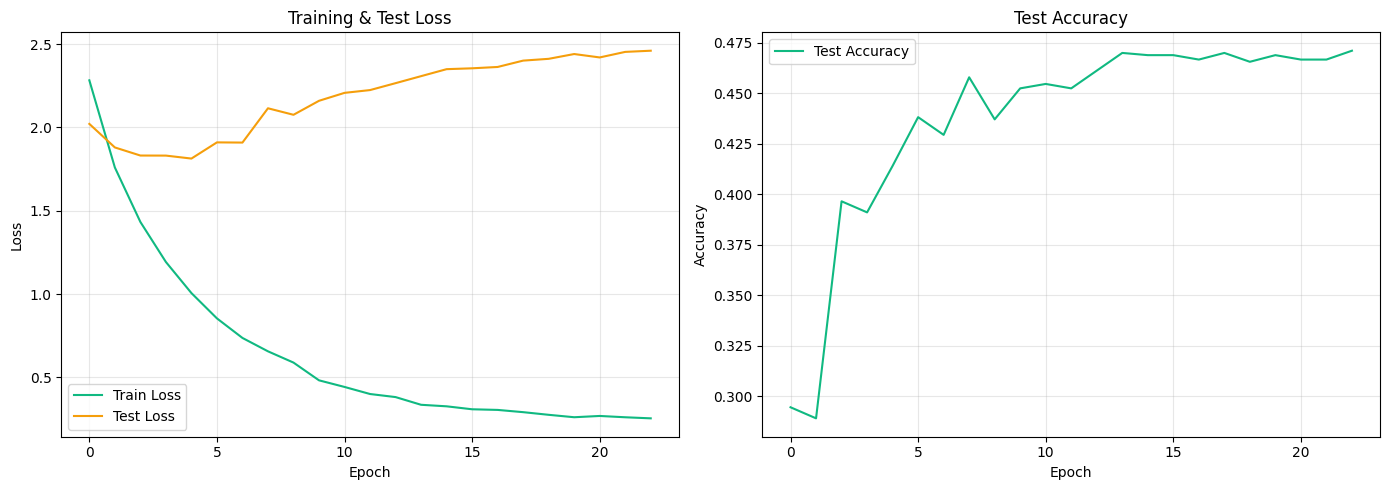

In [33]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', color='#10b981')
ax1.plot(test_losses, label='Test Loss', color='#f59e0b')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Test Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(test_accs, label='Test Accuracy', color='#10b981')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('textcnn_training_curves.png', dpi=150)
plt.show()

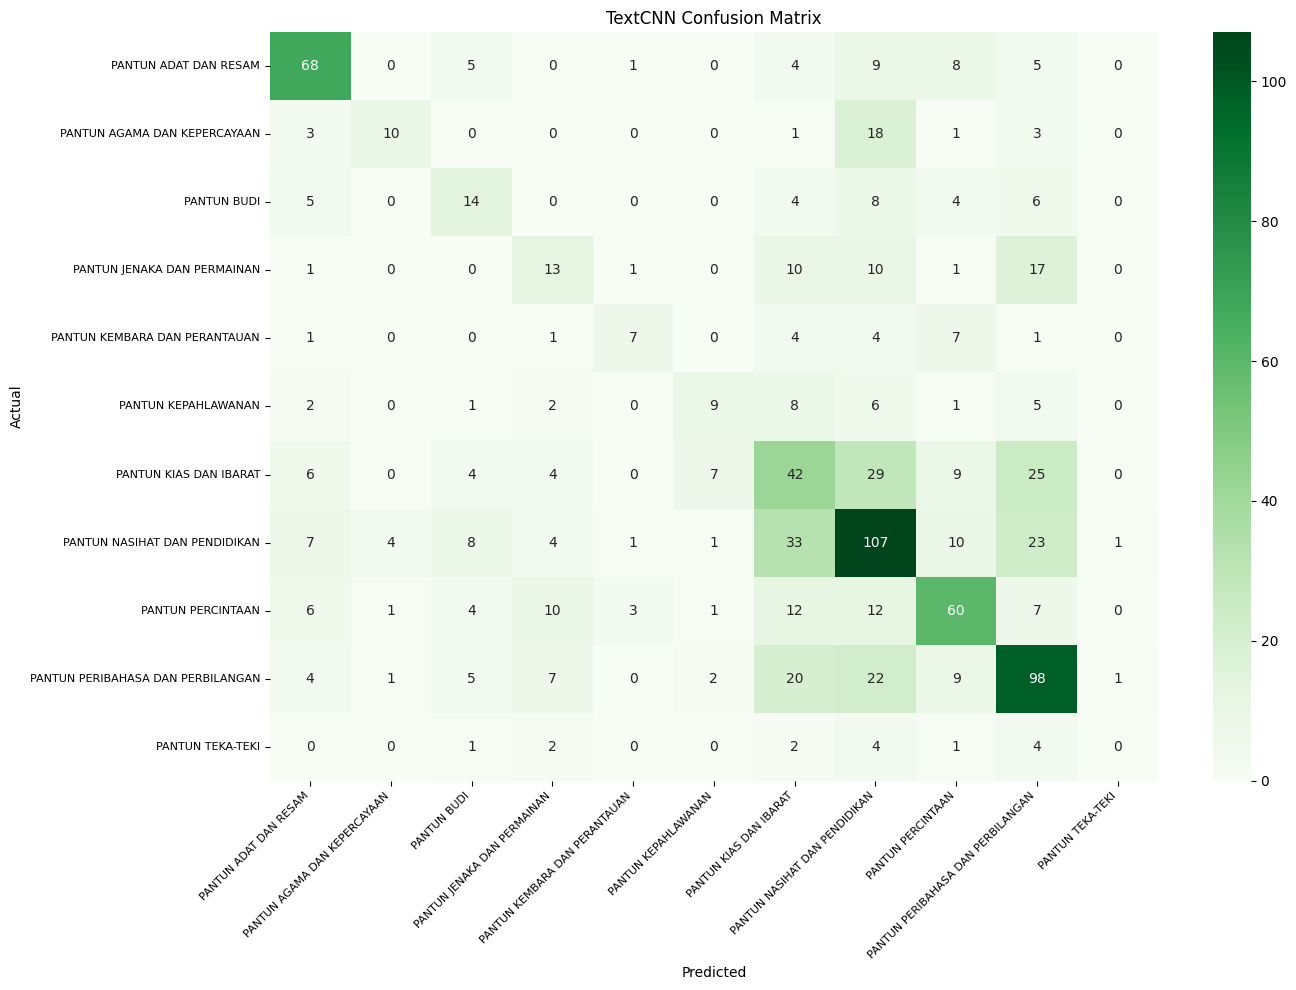

In [34]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('TextCNN Confusion Matrix')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('textcnn_confusion_matrix.png', dpi=150)
plt.show()

## 7. Export Model for Flask Backend

Download `textcnn_best.pth` and place it in `backend/models/` on your local machine.

In [35]:
# Save metrics
import shutil
metrics = {
    'accuracy': float(acc),
    'f1_score': float(f1),
    'use_pembayang': USE_PEMBAYANG,
    'model_type': 'TextCNN',
    'embed_dim': EMBED_DIM,
    'kernel_sizes': KERNEL_SIZES,
    'num_filters': NUM_FILTERS,
    'vocab_size': len(vocab),
    'max_len': MAX_LEN,
    'num_epochs_trained': len(train_losses),
}

with open('textcnn_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# Save to Google Drive
DRIVE_OUTPUT = '/content/drive/MyDrive/pantun_models/'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
shutil.copy('textcnn_best.pth', DRIVE_OUTPUT + 'textcnn_best.pth')
shutil.copy('textcnn_metrics.json', DRIVE_OUTPUT + 'textcnn_metrics.json')

print("\n📦 Files saved to Google Drive:")
print(f"  1. {DRIVE_OUTPUT}textcnn_best.pth")
print(f"  2. {DRIVE_OUTPUT}textcnn_metrics.json")
print("\n📁 Download from Drive and place in: backend/models/")



📦 Files saved to Google Drive:
  1. /content/drive/MyDrive/pantun_models/textcnn_best.pth
  2. /content/drive/MyDrive/pantun_models/textcnn_metrics.json

📁 Download from Drive and place in: backend/models/
